### 4.4 Decision: Why We Abandoned the Standalone MBTI Classifier

The RQ2 results above reveal three critical findings that led us to **abandon the standalone MBTI classifier** and instead derive MBTI types from Big Five profiles:

**1. Near-chance classification performance**

| Dimension | Macro-F1 |
|-----------|----------|
| I/E | 0.519 |
| N/S | 0.422 |
| T/F | 0.564 |
| J/P | 0.535 |

All four dimensions hover near the random-baseline of 0.50 for binary classification. The N/S dimension (0.422) actually performs *below* chance, indicating the model learns noise rather than signal. A classifier this weak would produce unreliable and inconsistent type assignments.

**2. Shortcut artifacts inflate apparent accuracy**

Our artifact detection experiment (§4.1–4.3) shows that when explicit MBTI mentions (e.g., "I'm an INTJ") are removed from the text, classification performance drops further. This means the classifier partly relies on users self-declaring their type — a circular shortcut that provides no predictive value for new users who have not yet been typed.

**3. Big Five → MBTI derivation is more principled**

The well-established correspondence between Big Five traits and MBTI dimensions (McCrae & Costa, 1989; Furnham, 1996) provides a theoretically grounded alternative:

- **E/I** ← primarily Extraversion (+ minor Agreeableness, Neuroticism)
- **N/S** ← primarily Openness (+ minor Conscientiousness, Extraversion)
- **T/F** ← primarily Agreeableness (+ minor Openness, Neuroticism)
- **J/P** ← primarily Conscientiousness (+ minor Neuroticism, Openness)

Since our Big Five classifier achieves substantially higher performance (Macro-F1 0.72–0.78 per trait), deriving MBTI from these more reliable Big Five predictions produces more accurate and stable type assignments than direct MBTI text classification.

**Conclusion:** The `mbti_predictors.pkl` file was removed from the deployment. In the Streamlit app, MBTI types are derived from the Big Five profile using multi-trait weighted mapping, avoiding the shortcut-artifact problem entirely while leveraging the stronger Big Five signal.

# PersonaPath: Adaptive Personality Explorer
## SIADS 699 Capstone
### Team Foundry

**Pipeline Overview:**
1. Data Loading & EDA (Essays Big Five, Pandora Big Five, MBTI Reddit)
2. Big Five Trait Prediction (RQ1a)
3. MBTI Classification & Shortcut Artifact Detection (RQ2)
4. Construct-Free vs Construct-Based Comparison (RQ1b)
5. Adaptive Questioning Simulation (RQ3)
6. O*NET Career Alignment & Domain Shift Analysis (RQ4)
7. Streamlit App Integration

---
## 0. Environment Setup

In [ ]:
# ============================================================
# 0.1 Install Dependencies
# ============================================================
!pip install -q datasets transformers sentence-transformers scikit-learn \
    scipy matplotlib seaborn pandas numpy torch accelerate

In [ ]:
# ============================================================
# 0.2 Imports
# ============================================================
import os, warnings, re, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error, f1_score, accuracy_score, classification_report,
    confusion_matrix, silhouette_score, calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import calibration_curve
from scipy.stats import pearsonr, entropy
from scipy.spatial.distance import cosine

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


---
## 1. Data Loading & EDA

### 1.1 Essays Big Five Dataset
Structured essays with validated Big Five labels (binary per trait).  
**License**: Apache-2.0

In [ ]:
# ============================================================
# 1.1 Load Essays Big Five
# ============================================================
essays_ds = load_dataset('jingjietan/essays-big5')
print(essays_ds)

# Convert to DataFrame
essays_train = pd.DataFrame(essays_ds['train'])
essays_val   = pd.DataFrame(essays_ds['validation'])
essays_test  = pd.DataFrame(essays_ds['test'])
essays_all   = pd.concat([essays_train, essays_val, essays_test], ignore_index=True)

BIG5_TRAITS = ['O', 'C', 'E', 'A', 'N']
TRAIT_NAMES = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']

print(f'\nTotal essays: {len(essays_all)}')
print(f'Columns: {essays_all.columns.tolist()}')
print(f'\nTrait distribution:')
for t, name in zip(BIG5_TRAITS, TRAIT_NAMES):
    counts = essays_all[t].value_counts().to_dict()
    print(f'  {name} ({t}): {counts}')

print(f'\nText length stats:')
essays_all['text_len'] = essays_all['text'].str.len()
print(essays_all['text_len'].describe())

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/795k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/953k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1578 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/395 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/494 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__'],
        num_rows: 1578
    })
    validation: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__'],
        num_rows: 395
    })
    test: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__'],
        num_rows: 494
    })
})

Total essays: 2467
Columns: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__']

Trait distribution:
  Openness (O): {'1': 1271, '0': 1196}
  Conscientiousness (C): {'1': 1253, '0': 1214}
  Extraversion (E): {'1': 1276, '0': 1191}
  Agreeableness (A): {'1': 1310, '0': 1157}
  Neuroticism (N): {'0': 1234, '1': 1233}

Text length stats:
count     2467.000000
mean      3296.283340
std       1287.282526
min        159.000000
25%       2408.000000
50%       3164.000000
75%       4079.000000
max      12852.000000
Name: text_len, dtype: float64


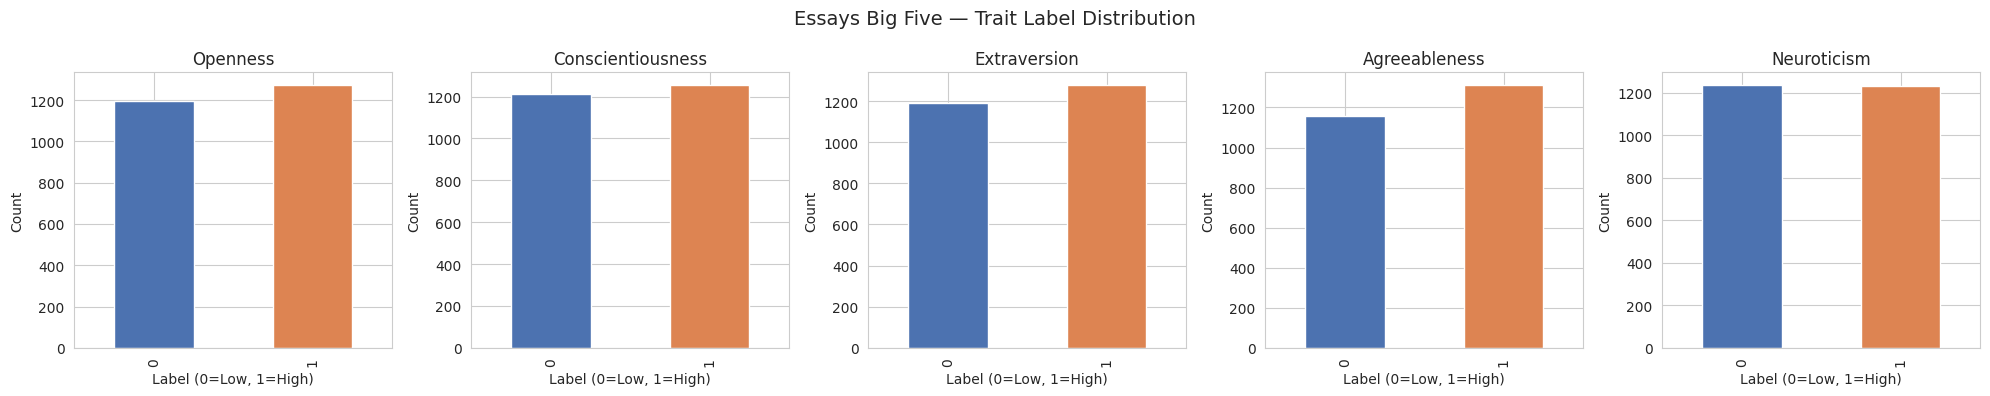

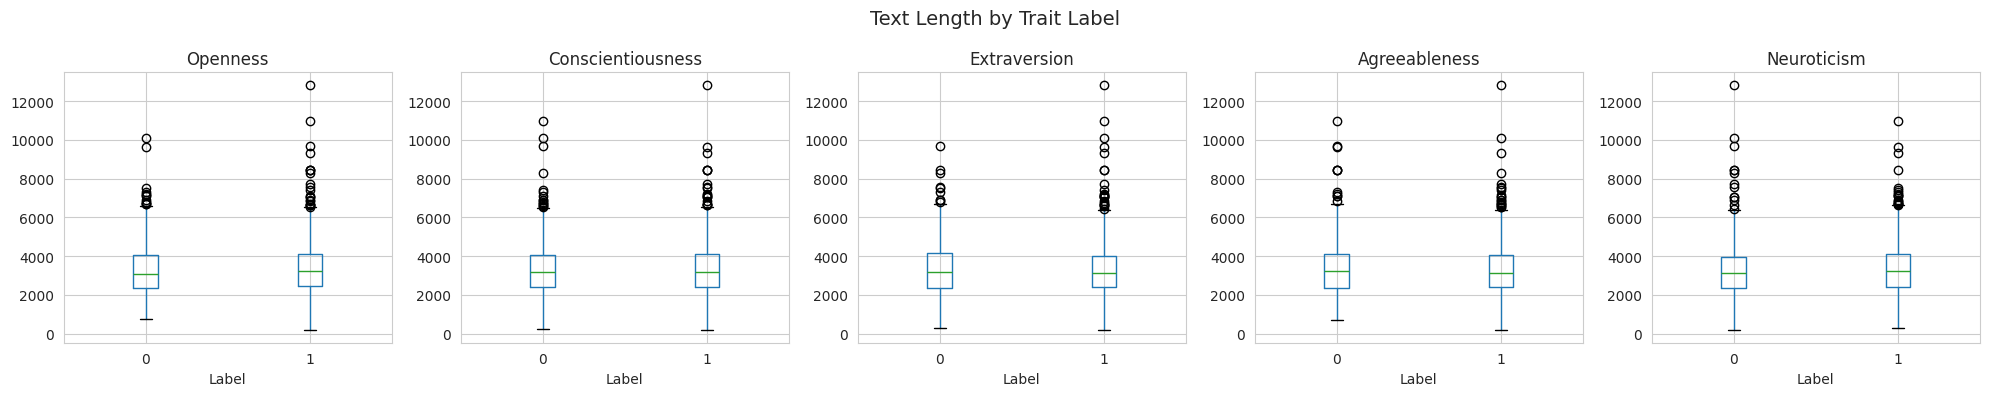

In [ ]:
# ============================================================
# 1.1b EDA Visualizations - Essays
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (t, name) in enumerate(zip(BIG5_TRAITS, TRAIT_NAMES)):
    essays_all[t].value_counts().sort_index().plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Label (0=Low, 1=High)')
    axes[i].set_ylabel('Count')
plt.suptitle('Essays Big Five — Trait Label Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# Text length by trait
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (t, name) in enumerate(zip(BIG5_TRAITS, TRAIT_NAMES)):
    essays_all.boxplot(column='text_len', by=t, ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('Label')
plt.suptitle('Text Length by Trait Label', fontsize=14)
plt.tight_layout()
plt.show()

### 1.2 Pandora Big Five Dataset
Informal Reddit comments with Big Five trait scores.  
**License**: Research-only (University of Zagreb TakeLab). No redistribution.

In [ ]:
# ============================================================
# 1.2 Load Pandora Big Five
# ============================================================
pandora_ds = load_dataset('jingjietan/pandora-big5')
print(pandora_ds)

pandora_train = pd.DataFrame(pandora_ds['train'])
pandora_val   = pd.DataFrame(pandora_ds.get('validation', pandora_ds['train'][:0]))
pandora_test  = pd.DataFrame(pandora_ds.get('test', pandora_ds['train'][:0]))
pandora_all   = pd.concat([pandora_train, pandora_val, pandora_test], ignore_index=True)

print(f'\nTotal Pandora entries: {len(pandora_all)}')
print(f'Columns: {pandora_all.columns.tolist()}')
print(pandora_all.head(3))

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/163M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/164M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/81.8M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/102M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1924201 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/481051 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/601314 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__'],
        num_rows: 1924201
    })
    validation: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__'],
        num_rows: 481051
    })
    test: Dataset({
        features: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__'],
        num_rows: 601314
    })
})

Total Pandora entries: 3006566
Columns: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__']
      O     C     E     A     N  ptype  \
0  74.0  96.0  17.0  96.0  47.0     26   
1  60.0  73.0  42.0  40.0  72.0     25   
2  17.0  35.0  88.0  70.0   9.0      6   

                                                text  __index_level_0__  
0  Why? He was a professional chef and lifelong f...             580542  
1                                Reince Priebus too.             305867  
2                  Being given the chance to live...            1983719  


Pandora trait columns: ['O', 'C', 'E', 'A', 'N']


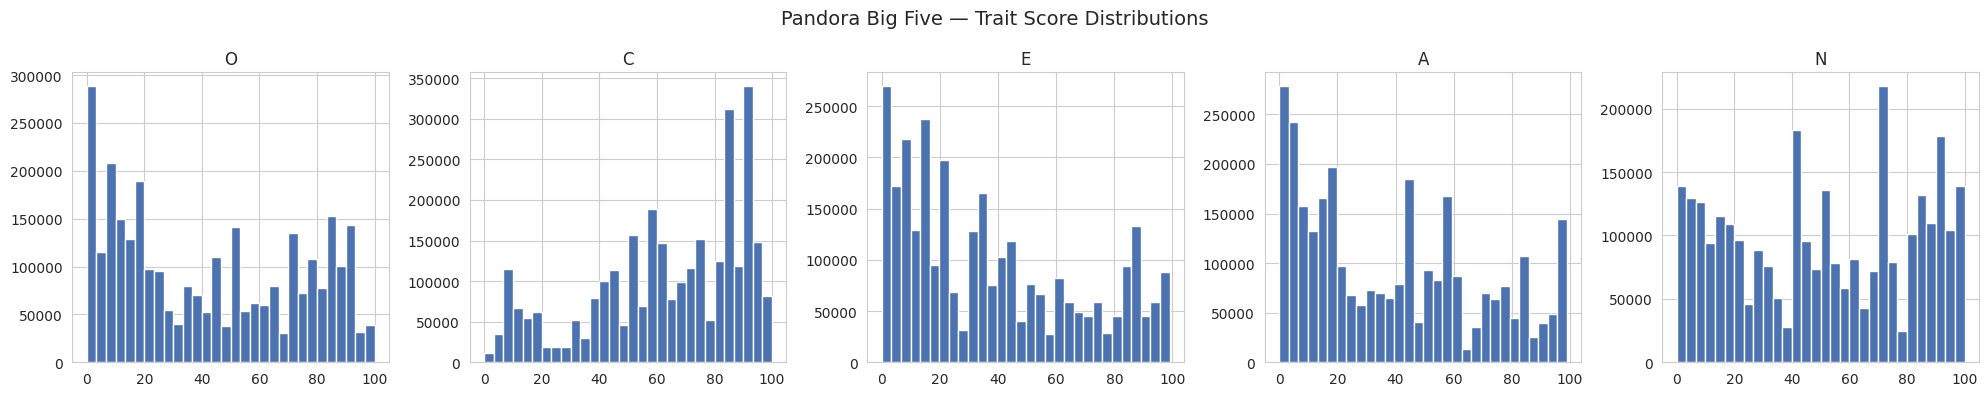

In [ ]:
# ============================================================
# 1.2b Pandora EDA — trait score distributions
# ============================================================
# Identify Big Five columns in Pandora (may vary by dataset version)
pandora_trait_cols = [c for c in pandora_all.columns if c in
    ['O', 'C', 'E', 'A', 'N', 'openness', 'conscientiousness',
     'extraversion', 'agreeableness', 'neuroticism']]
print(f'Pandora trait columns: {pandora_trait_cols}')

if pandora_trait_cols:
    fig, axes = plt.subplots(1, len(pandora_trait_cols), figsize=(4*len(pandora_trait_cols), 4))
    if len(pandora_trait_cols) == 1:
        axes = [axes]
    for i, col in enumerate(pandora_trait_cols):
        pandora_all[col].dropna().hist(bins=30, ax=axes[i], color='#4C72B0', edgecolor='white')
        axes[i].set_title(col)
    plt.suptitle('Pandora Big Five — Trait Score Distributions', fontsize=14)
    plt.tight_layout()
    plt.show()

### 1.3 MBTI Reddit Dataset
MBTI-labeled Reddit posts from your Google Drive CSV files.  
**License**: CC0 (Kaggle self-reported) — see Data Access Statement for caveats.

In [ ]:
# ============================================================
# 1.3 Load MBTI Reddit Data (from Google Drive)
# ============================================================
import os
import glob
import pandas as pd
from google.colab import drive

# 1. Mount Google Drive
# Set force_remount=True to ensure the latest file structure is visible
drive.mount('/content/drive', force_remount=True)

# 2. Define the base path and locate the target folder
# This logic automatically handles potential hidden spaces or encoding issues in folder names
BASE_PATH = '/content/drive/MyDrive/'
matching_folders = [f for f in os.listdir(BASE_PATH) if "Myers" in f]

if not matching_folders:
    print("Error: Could not find a folder containing 'Myers' in My Drive.")
else:
    # Set the verified directory path
    MBTI_DIR = os.path.join(BASE_PATH, matching_folders[0])
    print(f"Verified directory path: '{MBTI_DIR}'")

    # 3. Identify CSV files matching the naming pattern
    # Using glob to find all files starting with 'full_pull_' and ending in '.csv'
    search_pattern = os.path.join(MBTI_DIR, 'full_pull_*.csv')
    csv_files = sorted(glob.glob(search_pattern))

    print(f'Found {len(csv_files)} CSV files')

    if len(csv_files) == 0:
        print("Error: No files matching 'full_pull_*.csv' found in the directory.")
        print("Actual files in directory:", os.listdir(MBTI_DIR)[:5])
    else:
        # 4. Load data into DataFrames
        # Set NUM_FILES = 2 for initial prototyping with large datasets
        NUM_FILES = 2
        mbti_dfs = []

        for f in csv_files[:NUM_FILES]:
            file_name = os.path.basename(f)
            print(f'Loading {file_name}...')

            try:
                # Use low_memory=False to handle large files efficiently
                # on_bad_lines='skip' ensures the script continues if a row is corrupted
                df = pd.read_csv(f,
                                 usecols=['flair_text', 'body', 'subreddit', 'author'],
                                 dtype=str,
                                 on_bad_lines='skip',
                                 low_memory=False)
                mbti_dfs.append(df)
            except Exception as e:
                print(f"Warning: Failed to load {file_name}. Error: {e}")

        # 5. Concatenate individual DataFrames into one master DataFrame
        if mbti_dfs:
            mbti_raw = pd.concat(mbti_dfs, ignore_index=True)
            print(f'\nTotal MBTI rows loaded: {len(mbti_raw):,}')
            print(mbti_raw.head(3))
        else:
            print("Error: No data was successfully loaded.")

Mounted at /content/drive
Verified directory path: '/content/drive/MyDrive/Myers Briggs Personality Tags On Reddit Data '
Found 18 CSV files
Loading full_pull_v2000000000000.csv...
Loading full_pull_v2000000000001.csv...

Total MBTI rows loaded: 3,110,985
                 flair_text  \
0  INFP: The Dreamer Senpai   
1        INTP: The Theorist   
2         INFP: The Dreamer   

                                                body subreddit          author  
0                            Lol that's why I left.       entp  LadyBanterbury  
1  I was just about to post "I try telling people...      INTP         Finarin  
2  My first thought was Pepsi or something. Proba...       WTF       xanplease  


In [ ]:
# ============================================================
# 1.3b Parse MBTI type from flair_text
# ============================================================
MBTI_TYPES = ['INTJ','INTP','ENTJ','ENTP','INFJ','INFP','ENFJ','ENFP',
              'ISTJ','ISFJ','ESTJ','ESFJ','ISTP','ISFP','ESTP','ESFP']

def extract_mbti(flair):
    """Extract 4-letter MBTI type from flair text."""
    if pd.isna(flair):
        return None
    flair_upper = flair.upper()
    for t in MBTI_TYPES:
        if t in flair_upper:
            return t
    return None

mbti_raw['mbti_type'] = mbti_raw['flair_text'].apply(extract_mbti)
mbti_labeled = mbti_raw.dropna(subset=['mbti_type', 'body']).copy()
mbti_labeled = mbti_labeled[mbti_labeled['body'].str.len() > 20]  # filter very short

print(f'Rows with valid MBTI label: {len(mbti_labeled):,}')
print(f'\nMBTI Type Distribution:')
type_counts = mbti_labeled['mbti_type'].value_counts()
print(type_counts)

# 4-dimension binary labels
mbti_labeled['I_E'] = mbti_labeled['mbti_type'].str[0]  # I vs E
mbti_labeled['N_S'] = mbti_labeled['mbti_type'].str[1]  # N vs S
mbti_labeled['T_F'] = mbti_labeled['mbti_type'].str[2]  # T vs F
mbti_labeled['J_P'] = mbti_labeled['mbti_type'].str[3]  # J vs P

Rows with valid MBTI label: 2,802,770

MBTI Type Distribution:
mbti_type
INFP    550571
INTP    541005
INFJ    490061
ENTP    404051
INTJ    345800
ENTJ    118527
ISTP    101688
ENFP     90463
ENFJ     54274
ESTP     23220
ISFJ     21266
ISTJ     19858
ISFP     16581
ESTJ     11192
ESFP      7253
ESFJ      6960
Name: count, dtype: int64


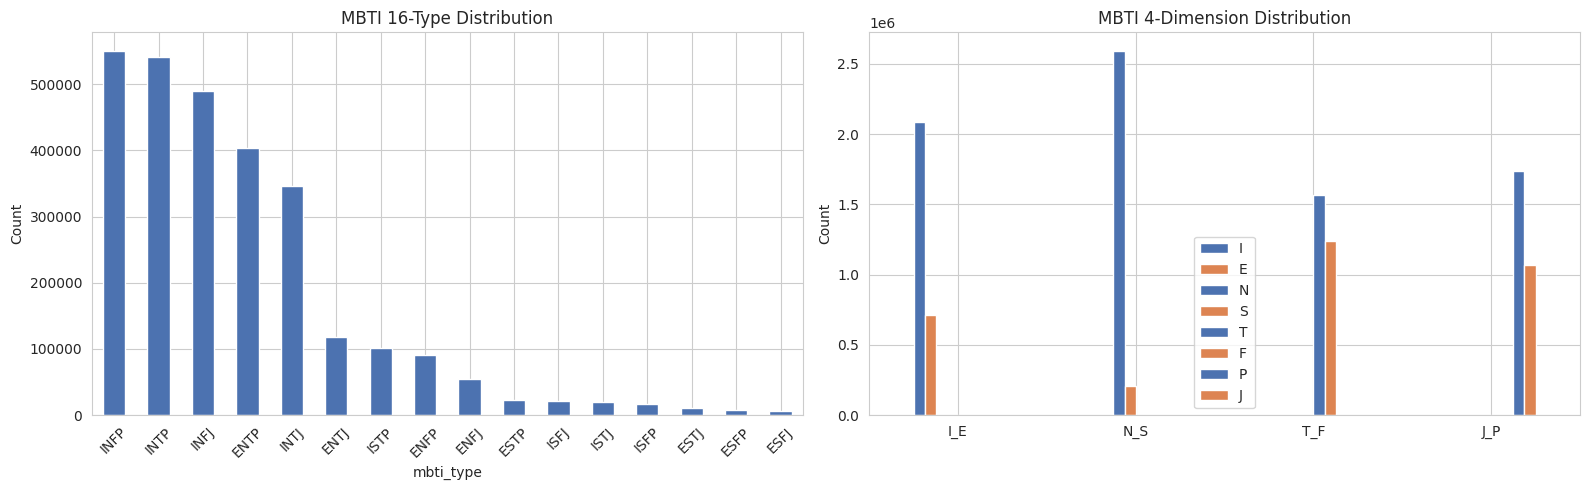


Class Imbalance Ratios (max/min):
  I_E: 2.91x ({'I': 2086830, 'E': 715940})
  N_S: 12.47x ({'N': 2594752, 'S': 208018})
  T_F: 1.26x ({'T': 1565341, 'F': 1237429})
  J_P: 1.62x ({'P': 1734832, 'J': 1067938})


In [ ]:
# ============================================================
# 1.3c MBTI EDA — Class imbalance visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full 16-type distribution
type_counts.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('MBTI 16-Type Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# 4-dimension distribution
dim_data = {}
for dim in ['I_E', 'N_S', 'T_F', 'J_P']:
    dim_data[dim] = mbti_labeled[dim].value_counts().to_dict()
dim_df = pd.DataFrame(dim_data).T
dim_df.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('MBTI 4-Dimension Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Class imbalance ratio
print('\nClass Imbalance Ratios (max/min):')
for dim in ['I_E', 'N_S', 'T_F', 'J_P']:
    vc = mbti_labeled[dim].value_counts()
    print(f'  {dim}: {vc.max()/vc.min():.2f}x ({vc.to_dict()})')

---
## 2. Embedding Generation (Shared Foundation)

Generate Sentence-BERT embeddings for all datasets. These embeddings feed into:
- Big Five prediction (Pipeline A)
- Construct-free clustering (Pipeline B)
- MBTI classification

In [ ]:
# ============================================================
# 2.1 Load Sentence-BERT Model
# ============================================================
SBERT_MODEL = 'all-MiniLM-L6-v2'  # Fast & good quality; upgrade to 'all-mpnet-base-v2' for production
sbert = SentenceTransformer(SBERT_MODEL, device=device)
print(f'Loaded {SBERT_MODEL} (dim={sbert.get_sentence_embedding_dimension()})')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded all-MiniLM-L6-v2 (dim=384)


In [ ]:
# ============================================================
# 2.2 Encode Essays Dataset
# ============================================================
# Truncate long texts to first 512 tokens worth of chars (~2000 chars)
MAX_CHARS = 2000

essays_texts = essays_all['text'].str[:MAX_CHARS].tolist()
print(f'Encoding {len(essays_texts)} essays...')
essays_embeddings = sbert.encode(essays_texts, batch_size=64, show_progress_bar=True,
                                  convert_to_numpy=True)
print(f'Essays embeddings shape: {essays_embeddings.shape}')

Encoding 2467 essays...


Batches:   0%|          | 0/39 [00:00<?, ?it/s]

Essays embeddings shape: (2467, 384)


In [ ]:
# ============================================================
# 2.3 Encode Pandora Dataset (Chunked + Checkpoint + Resume)
# Safe Version: float32 + memmap merge to avoid kernel crash
# ============================================================

import gc
import numpy as np
from pathlib import Path

# ---------- Config ----------
MAX_CHARS = 500
CHUNK_SIZE = 20000
BATCH_SIZE = 64

SAVE_DIR = Path("/content/drive/MyDrive/PersonaPath_Models/pandora_chunks")
FINAL_MEMMAP_PATH = Path("/content/drive/MyDrive/PersonaPath_Models/pandora_embeddings_full.dat")
FINAL_NPY_PATH = Path("/content/drive/MyDrive/PersonaPath_Models/pandora_embeddings_full.npy")

# Set to True only if you really need one final .npy file.
# Keeping this False is safer for large datasets.
SAVE_FINAL_NPY = False

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Select text column ----------
text_col_pandora = "text" if "text" in pandora_all.columns else pandora_all.columns[0]
num_rows = len(pandora_all)

print(f"Using text column: {text_col_pandora}")
print(f"Total Pandora rows: {num_rows}")
print(f"Chunk size: {CHUNK_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max chars per text: {MAX_CHARS}")
print(f"Chunk save dir: {SAVE_DIR}")

# ============================================================
# Step 1: Encode in chunks with resume
# ============================================================
for start in range(0, num_rows, CHUNK_SIZE):
    end = min(start + CHUNK_SIZE, num_rows)
    chunk_id = start // CHUNK_SIZE
    out_file = SAVE_DIR / f"pandora_emb_{chunk_id:04d}.npy"

    if out_file.exists():
        print(f"[Skip] Chunk {chunk_id:04d} already exists: {out_file.name}")
        continue

    print(f"\n[Encode] Chunk {chunk_id:04d} | rows {start}:{end}")

    chunk_texts = (
        pandora_all.iloc[start:end][text_col_pandora]
        .fillna("")
        .astype(str)
        .str[:MAX_CHARS]
        .tolist()
    )

    # Encode and force float32 to reduce memory/storage
    chunk_emb = sbert.encode(
        chunk_texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True
    ).astype(np.float32)

    np.save(out_file, chunk_emb)
    print(f"[Saved] {out_file.name} | shape={chunk_emb.shape} | dtype={chunk_emb.dtype}")

    # Free memory
    del chunk_texts
    del chunk_emb
    gc.collect()

print("\nAll available chunks encoded.")

# ============================================================
# Step 2: Collect chunk files
# ============================================================
chunk_files = sorted(SAVE_DIR.glob("pandora_emb_*.npy"))

if len(chunk_files) == 0:
    raise ValueError("No chunk embedding files found. Nothing to merge.")

print(f"\nFound {len(chunk_files)} chunk files.")

# ============================================================
# Step 3: Inspect chunk shapes and validate consistency
# ============================================================
first_arr = np.load(chunk_files[0], mmap_mode="r")
emb_dim = first_arr.shape[1]
dtype = first_arr.dtype

print(f"Embedding dimension: {emb_dim}")
print(f"Embedding dtype: {dtype}")

total_rows = 0
for f in chunk_files:
    arr = np.load(f, mmap_mode="r")
    if len(arr.shape) != 2:
        raise ValueError(f"Chunk file {f.name} is not 2D. Found shape={arr.shape}")
    if arr.shape[1] != emb_dim:
        raise ValueError(
            f"Embedding dimension mismatch in {f.name}: "
            f"expected {emb_dim}, got {arr.shape[1]}"
        )
    total_rows += arr.shape[0]
    print(f"[Checked] {f.name} | shape={arr.shape}")

print(f"\nTotal rows across chunk files: {total_rows}")

# ============================================================
# Step 4: Merge safely using memmap
# ============================================================
print(f"\n[Merge] Writing memmap to: {FINAL_MEMMAP_PATH}")

merged = np.memmap(
    FINAL_MEMMAP_PATH,
    dtype=dtype,
    mode="w+",
    shape=(total_rows, emb_dim)
)

cursor = 0
for f in chunk_files:
    arr = np.load(f, mmap_mode="r")
    n_rows = arr.shape[0]

    merged[cursor:cursor + n_rows] = arr
    print(f"[Merged] {f.name} -> rows {cursor}:{cursor + n_rows}")

    cursor += n_rows
    del arr
    gc.collect()

merged.flush()
print(f"\n[Saved memmap] {FINAL_MEMMAP_PATH}")
print(f"Final merged shape: ({total_rows}, {emb_dim})")

# ============================================================
# Step 5: Optional sanity check
# ============================================================
expected_rows = num_rows
actual_rows = total_rows

if actual_rows == expected_rows:
    print(f"[OK] Row count matches: {actual_rows}")
else:
    print(f"[Warning] Row count mismatch: expected={expected_rows}, actual={actual_rows}")

# ============================================================
# Step 6: Optional save to one .npy file
# Warning: this may still use substantial memory for very large data
# ============================================================
if SAVE_FINAL_NPY:
    print(f"\n[Optional] Converting memmap to final .npy: {FINAL_NPY_PATH}")
    final_array = np.asarray(merged)
    np.save(FINAL_NPY_PATH, final_array)
    print(f"[Saved final npy] {FINAL_NPY_PATH}")
    del final_array
    gc.collect()

# Cleanup
del merged
gc.collect()

print("\nDone.")

Using text column: text
Total Pandora rows: 3006566
Chunk size: 20000
Batch size: 64
Max chars per text: 500
Chunk save dir: /content/drive/MyDrive/PersonaPath_Models/pandora_chunks

[Encode] Chunk 0000 | rows 0:20000


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

[Saved] pandora_emb_0000.npy | shape=(20000, 384) | dtype=float32

[Encode] Chunk 0001 | rows 20000:40000


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

[Saved] pandora_emb_0001.npy | shape=(20000, 384) | dtype=float32

[Encode] Chunk 0002 | rows 40000:60000


...

[Saved] pandora_emb_0067.npy | shape=(20000, 384) | dtype=float32

[Encode] Chunk 0068 | rows 1360000:1380000


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

[Saved] pandora_emb_0068.npy | shape=(20000, 384) | dtype=float32

[Encode] Chunk 0069 | rows 1380000:1400000


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ============================================================
# 2.4 Encode MBTI Dataset (sample for efficiency)
# ============================================================
MBTI_SAMPLE_SIZE = 50000  # Adjust based on Colab RAM/GPU

if len(mbti_labeled) > MBTI_SAMPLE_SIZE:
    mbti_sample = mbti_labeled.sample(MBTI_SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
else:
    mbti_sample = mbti_labeled.reset_index(drop=True)

mbti_texts = mbti_sample['body'].str[:MAX_CHARS].tolist()
print(f'Encoding {len(mbti_texts)} MBTI posts...')
mbti_embeddings = sbert.encode(mbti_texts, batch_size=64, show_progress_bar=True,
                                convert_to_numpy=True)
print(f'MBTI embeddings shape: {mbti_embeddings.shape}')

Encoding 50000 MBTI posts...


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

MBTI embeddings shape: (50000, 384)


---
## 3. RQ1a: Big Five Trait Prediction

**Question**: Can NLP models reliably infer Big Five traits?  
**Metrics**: Per-trait Pearson r, RMSE  
**Baselines**: TF-IDF + Ridge vs. SBERT + Ridge vs. SBERT + GBR

In [ ]:
# ============================================================
# 3.1 Prepare train/test splits (Essays)
# ============================================================
# Use original splits from HuggingFace
train_idx = list(range(len(essays_train)))
val_idx   = list(range(len(essays_train), len(essays_train) + len(essays_val)))
test_idx  = list(range(len(essays_train) + len(essays_val),
                       len(essays_train) + len(essays_val) + len(essays_test)))

X_train_emb = essays_embeddings[train_idx]
X_val_emb   = essays_embeddings[val_idx]
X_test_emb  = essays_embeddings[test_idx]

# TF-IDF baseline
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(essays_train['text'].str[:MAX_CHARS])
X_val_tfidf   = tfidf.transform(essays_val['text'].str[:MAX_CHARS])
X_test_tfidf  = tfidf.transform(essays_test['text'].str[:MAX_CHARS])

print(f'SBERT train: {X_train_emb.shape}, val: {X_val_emb.shape}, test: {X_test_emb.shape}')
print(f'TF-IDF train: {X_train_tfidf.shape}')

SBERT train: (1578, 384), val: (395, 384), test: (494, 384)
TF-IDF train: (1578, 5000)


In [ ]:
# ============================================================
# 3.2 Per-Trait Binary Classification (Essays are binary labels)
# ============================================================
results_b5 = []

for trait, name in zip(BIG5_TRAITS, TRAIT_NAMES):
    y_train = essays_train[trait].astype(int).values
    y_test  = essays_test[trait].astype(int).values

    # --- Baseline 1: TF-IDF + Logistic Regression ---
    lr_tfidf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
    lr_tfidf.fit(X_train_tfidf, y_train)
    pred_tfidf = lr_tfidf.predict(X_test_tfidf)
    prob_tfidf = lr_tfidf.predict_proba(X_test_tfidf)[:, 1]

    # --- Model 2: SBERT + Logistic Regression ---
    lr_sbert = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
    lr_sbert.fit(X_train_emb, y_train)
    pred_sbert = lr_sbert.predict(X_test_emb)
    prob_sbert = lr_sbert.predict_proba(X_test_emb)[:, 1]

    # --- Model 3: SBERT + Random Forest ---
    rf_sbert = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                      random_state=SEED, n_jobs=-1)
    rf_sbert.fit(X_train_emb, y_train)
    pred_rf = rf_sbert.predict(X_test_emb)
    prob_rf = rf_sbert.predict_proba(X_test_emb)[:, 1]

    for model_name, preds, probs in [
        ('TF-IDF + LR', pred_tfidf, prob_tfidf),
        ('SBERT + LR', pred_sbert, prob_sbert),
        ('SBERT + RF', pred_rf, prob_rf)
    ]:
        acc = accuracy_score(y_test, preds)
        f1  = f1_score(y_test, preds, average='macro')
        r, p_val = pearsonr(y_test, probs)
        results_b5.append({
            'Trait': name, 'Model': model_name,
            'Accuracy': acc, 'Macro-F1': f1,
            'Pearson_r': r, 'p_value': p_val
        })

results_b5_df = pd.DataFrame(results_b5)
print('\n=== RQ1a: Big Five Prediction Results (Essays, Test Set) ===')
print(results_b5_df.to_string(index=False))


=== RQ1a: Big Five Prediction Results (Essays, Test Set) ===
            Trait       Model  Accuracy  Macro-F1  Pearson_r      p_value
         Openness TF-IDF + LR  0.593117  0.593076   0.166716 1.975442e-04
         Openness  SBERT + LR  0.627530  0.626649   0.266295 1.825443e-09
         Openness  SBERT + RF  0.576923  0.574270   0.248532 2.168548e-08
Conscientiousness TF-IDF + LR  0.530364  0.529060   0.013641 7.623306e-01
Conscientiousness  SBERT + LR  0.530364  0.529060   0.039403 3.821690e-01
Conscientiousness  SBERT + RF  0.534413  0.532690   0.075336 9.441461e-02
     Extraversion TF-IDF + LR  0.550607  0.549714   0.103442 2.147874e-02
     Extraversion  SBERT + LR  0.562753  0.562574   0.119255 7.969988e-03
     Extraversion  SBERT + RF  0.536437  0.530619   0.078544 8.116006e-02
    Agreeableness TF-IDF + LR  0.556680  0.554179   0.117518 8.938304e-03
    Agreeableness  SBERT + LR  0.520243  0.519674   0.078826 8.006839e-02
    Agreeableness  SBERT + RF  0.518219  0.491118 

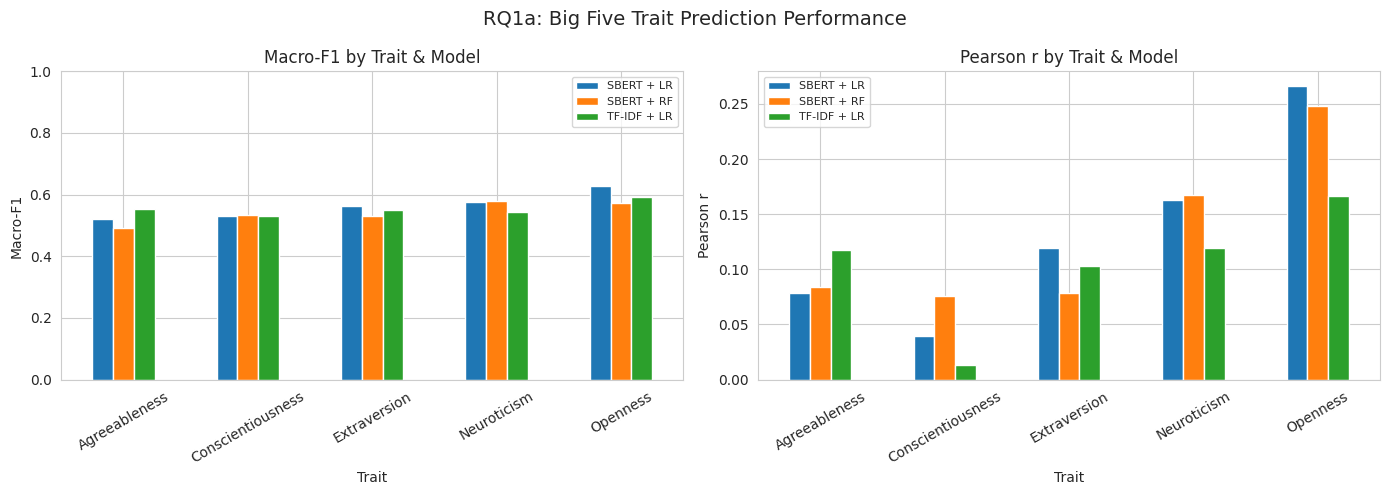

In [ ]:
# ============================================================
# 3.3 Visualization — Per-trait performance comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_f1 = results_b5_df.pivot(index='Trait', columns='Model', values='Macro-F1')
pivot_f1.plot(kind='bar', ax=axes[0], rot=30)
axes[0].set_title('Macro-F1 by Trait & Model')
axes[0].set_ylabel('Macro-F1')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

pivot_r = results_b5_df.pivot(index='Trait', columns='Model', values='Pearson_r')
pivot_r.plot(kind='bar', ax=axes[1], rot=30)
axes[1].set_title('Pearson r by Trait & Model')
axes[1].set_ylabel('Pearson r')
axes[1].legend(fontsize=8)

plt.suptitle('RQ1a: Big Five Trait Prediction Performance', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. RQ2: MBTI Shortcut Artifact Detection

**Question**: To what extent do MBTI classifiers rely on explicit personality acronyms?  
**Method**: Compare classification with vs. without explicit MBTI mentions in text.

In [ ]:
# ============================================================
# 4.1 Create clean vs. artifact-containing text versions
# ============================================================
MBTI_PATTERN = re.compile(
    r'\b(' + '|'.join(MBTI_TYPES) + r')\b',
    re.IGNORECASE
)

# Count how many posts contain explicit MBTI mentions
mbti_sample['has_artifact'] = mbti_sample['body'].str.contains(MBTI_PATTERN, na=False)
artifact_rate = mbti_sample['has_artifact'].mean()
print(f'Posts containing explicit MBTI acronyms: {artifact_rate:.1%}')

# Create cleaned version (remove MBTI acronyms)
mbti_sample['body_clean'] = mbti_sample['body'].str.replace(MBTI_PATTERN, '[TYPE]', regex=True)

# Encode cleaned texts
print('Encoding cleaned texts...')
mbti_clean_texts = mbti_sample['body_clean'].str[:MAX_CHARS].tolist()
mbti_clean_embeddings = sbert.encode(mbti_clean_texts, batch_size=64,
                                      show_progress_bar=True, convert_to_numpy=True)

Posts containing explicit MBTI acronyms: 2.9%
Encoding cleaned texts...


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# 4.2 Classification: Original vs Clean text (per MBTI dimension)
# ============================================================
MBTI_DIMS = ['I_E', 'N_S', 'T_F', 'J_P']
MBTI_DIM_NAMES = ['Introversion/Extraversion', 'Intuition/Sensing',
                  'Thinking/Feeling', 'Judging/Perceiving']

artifact_results = []

for dim, dim_name in zip(MBTI_DIMS, MBTI_DIM_NAMES):
    le = LabelEncoder()
    y = le.fit_transform(mbti_sample[dim].values)

    # Stratified split
    X_tr, X_te, y_tr, y_te = train_test_split(
        np.arange(len(y)), y, test_size=0.2, stratify=y, random_state=SEED)

    for version, embs in [('Original', mbti_embeddings), ('Cleaned', mbti_clean_embeddings)]:
        clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
        clf.fit(embs[X_tr], y_tr)
        preds = clf.predict(embs[X_te])

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='macro')
        artifact_results.append({
            'Dimension': dim_name, 'Text': version,
            'Accuracy': acc, 'Macro-F1': f1
        })

artifact_df = pd.DataFrame(artifact_results)
print('\n=== RQ2: Shortcut Artifact Detection ===')
print(artifact_df.to_string(index=False))

# Compute F1 drop
print('\n--- F1 Drop (Original → Cleaned) ---')
for dim_name in MBTI_DIM_NAMES:
    orig = artifact_df[(artifact_df['Dimension']==dim_name) & (artifact_df['Text']=='Original')]['Macro-F1'].values[0]
    clean = artifact_df[(artifact_df['Dimension']==dim_name) & (artifact_df['Text']=='Cleaned')]['Macro-F1'].values[0]
    drop = orig - clean
    print(f'  {dim_name}: {orig:.3f} → {clean:.3f} (Δ = {drop:+.3f}, {drop/orig*100:+.1f}%)')


=== RQ2: Shortcut Artifact Detection ===
                Dimension     Text  Accuracy  Macro-F1
Introversion/Extraversion Original    0.5579  0.519143
Introversion/Extraversion  Cleaned    0.5529  0.514481
        Intuition/Sensing Original    0.5665  0.421923
        Intuition/Sensing  Cleaned    0.5648  0.421120
         Thinking/Feeling Original    0.5663  0.563983
         Thinking/Feeling  Cleaned    0.5664  0.563960
       Judging/Perceiving Original    0.5441  0.535496
       Judging/Perceiving  Cleaned    0.5383  0.529508

--- F1 Drop (Original → Cleaned) ---
  Introversion/Extraversion: 0.519 → 0.514 (Δ = +0.005, +0.9%)
  Intuition/Sensing: 0.422 → 0.421 (Δ = +0.001, +0.2%)
  Thinking/Feeling: 0.564 → 0.564 (Δ = +0.000, +0.0%)
  Judging/Perceiving: 0.535 → 0.530 (Δ = +0.006, +1.1%)


In [ ]:
# ============================================================
# 4.2b Save MBTI Classifiers
# ============================================================

mbti_predictors = {}

for dim in MBTI_DIMS:
  le = LabelEncoder()
  y = le.fit_transform(mbti_sample[dim].values)

  X_tr, X_te, y_tr, y_te = train_test_split(
      mbti_embeddings, y, test_size = 0.2, stratify = y, random_state = SEED
  )

  clf = LogisticRegression(max_iter=1000, class_weight = 'balanced', random_state = SEED)
  clf.fit(X_tr, y_tr)

  # Store model
  mbti_predictors[dim] = {
      'model': clf,
      'label_encoder': le
  }

  preds = clf.predict(X_te)
  f1 = f1_score(y_te, preds, average = 'macro')
  print(f'{dim}: Marco-F1 = {f1:.3f}')

print('\nMBTI predictors completed')

I_E: Marco-F1 = 0.519
N_S: Marco-F1 = 0.422
T_F: Marco-F1 = 0.564
J_P: Marco-F1 = 0.535

MBTI predictors completed


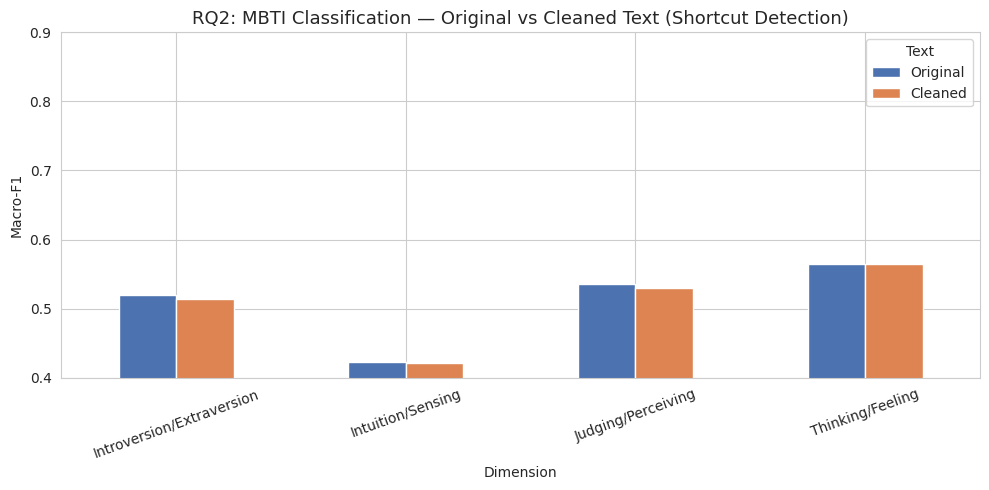

In [ ]:
# ============================================================
# 4.3 Visualization
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
pivot_art = artifact_df.pivot(index='Dimension', columns='Text', values='Macro-F1')
pivot_art[['Original', 'Cleaned']].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('RQ2: MBTI Classification — Original vs Cleaned Text (Shortcut Detection)', fontsize=13)
ax.set_ylabel('Macro-F1')
ax.set_ylim(0.4, 0.9)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

---
## 5. RQ1b: Construct-Based vs Construct-Free Pipelines

**Question**: Does mapping through Big Five improve career-cluster quality vs. direct embedding clustering?  

In [ ]:
# ============================================================
# 5.1 Pipeline A: Construct-Based (Embedding → Big5 → Cluster)
# ============================================================
# Train Big Five predictor on Essays, apply to all data
# Use the best model from RQ1a (e.g., SBERT + RF)

b5_predictors = {}
for trait in BIG5_TRAITS:
    y_train = essays_train[trait].astype(int).values
    clf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                  random_state=SEED, n_jobs=-1)
    clf.fit(X_train_emb, y_train)
    b5_predictors[trait] = clf

def predict_big5_profile(embeddings):
    """Returns N×5 array of Big Five probabilities."""
    profiles = np.column_stack([
        b5_predictors[t].predict_proba(embeddings)[:, 1]
        for t in BIG5_TRAITS
    ])
    return profiles

# Predict Big Five profiles for essays
essays_b5_profiles = predict_big5_profile(essays_embeddings)
print(f'Big Five profiles shape: {essays_b5_profiles.shape}')
print(f'Sample profile: {essays_b5_profiles[0].round(3)}')

In [ ]:
# ============================================================
# 5.2 Pipeline B: Construct-Free (Embedding → Direct Cluster)
# ============================================================
N_CLUSTERS = 6  # Number of work-style clusters

# Pipeline A: cluster on Big Five profiles
scaler_a = StandardScaler()
profiles_scaled = scaler_a.fit_transform(essays_b5_profiles)
km_a = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
labels_a = km_a.fit_predict(profiles_scaled)

# Pipeline B: cluster on raw SBERT embeddings
scaler_b = StandardScaler()
emb_scaled = scaler_b.fit_transform(essays_embeddings)
km_b = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
labels_b = km_b.fit_predict(emb_scaled)

# ============================================================
# 5.3 Compare Cluster Quality
# ============================================================
sil_a = silhouette_score(profiles_scaled, labels_a)
sil_b = silhouette_score(emb_scaled, labels_b)

ch_a = calinski_harabasz_score(profiles_scaled, labels_a)
ch_b = calinski_harabasz_score(emb_scaled, labels_b)

ari_ab = adjusted_rand_score(labels_a, labels_b)

print('=== RQ1b: Construct-Based vs Construct-Free ===')
print(f'\nPipeline A (Big Five → Cluster):')
print(f'  Silhouette Score:        {sil_a:.4f}')
print(f'  Calinski-Harabasz Index: {ch_a:.2f}')
print(f'\nPipeline B (Embedding → Cluster):')
print(f'  Silhouette Score:        {sil_b:.4f}')
print(f'  Calinski-Harabasz Index: {ch_b:.2f}')
print(f'\nAdjusted Rand Index (A vs B): {ari_ab:.4f}')
print(f'  (1.0 = identical, 0.0 = random agreement)')

In [ ]:
# ============================================================
# 5.4 Cluster profile analysis
# ============================================================
# What do Pipeline A clusters look like in Big Five space?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pipeline A: mean Big Five per cluster
cluster_profiles_a = pd.DataFrame(essays_b5_profiles, columns=TRAIT_NAMES)
cluster_profiles_a['Cluster'] = labels_a
means_a = cluster_profiles_a.groupby('Cluster')[TRAIT_NAMES].mean()
means_a.T.plot(kind='bar', ax=axes[0], legend=True)
axes[0].set_title('Pipeline A: Cluster Big Five Profiles')
axes[0].set_ylabel('Mean Probability')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

# Pipeline B: mean Big Five per cluster (how interpretable?)
cluster_profiles_b = pd.DataFrame(essays_b5_profiles, columns=TRAIT_NAMES)
cluster_profiles_b['Cluster'] = labels_b
means_b = cluster_profiles_b.groupby('Cluster')[TRAIT_NAMES].mean()
means_b.T.plot(kind='bar', ax=axes[1], legend=True)
axes[1].set_title('Pipeline B: Cluster Big Five Profiles (Post-hoc)')
axes[1].set_ylabel('Mean Probability')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('RQ1b: Do construct-free clusters align with personality dimensions?', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. RQ3: Adaptive Questioning Simulation

**Question**: Can adaptive questioning reduce uncertainty more efficiently than fixed/random baselines?  
**Method**: Simulate sequential question selection using Expected Information Gain (EIG).

In [ ]:
# ============================================================
# 6.1 Define Question Pool with Target Traits
# ============================================================
QUESTION_POOL = [
    # (question_text, primary_target_trait, secondary_target_trait)
    ("Describe what you enjoy doing in your free time.", 'O', 'E'),
    ("How do you typically organize your daily tasks or work?", 'C', None),
    ("When you meet someone new, how do you usually feel?", 'E', 'N'),
    ("How do you usually handle disagreements with others?", 'A', 'N'),
    ("What happens when you face an unexpected deadline?", 'N', 'C'),
    ("Describe a recent creative project or idea you had.", 'O', None),
    ("How do you decide whether to attend a social event?", 'E', None),
    ("When someone asks for help, what's your typical reaction?", 'A', None),
    ("How do you handle situations where things don't go as planned?", 'N', None),
    ("Describe your ideal work environment.", 'C', 'E'),
    ("How do you approach learning something completely new?", 'O', 'C'),
    ("What role do you usually take in group projects?", 'E', 'A'),
    ("How do you prepare for an important presentation?", 'C', 'N'),
    ("What kind of books, movies, or art do you enjoy?", 'O', None),
    ("How do you react when someone criticizes your work?", 'N', 'A'),
    ("Do you prefer working alone or in a team? Why?", 'E', 'A'),
    ("How important is maintaining a routine for you?", 'C', None),
    ("What motivates you to try something you've never done before?", 'O', 'E'),
    ("How do you feel about taking on leadership roles?", 'E', 'C'),
    ("What do you do when you feel overwhelmed or stressed?", 'N', None),
]

print(f'Question pool size: {len(QUESTION_POOL)}')
trait_coverage = Counter([q[1] for q in QUESTION_POOL])
print(f'Primary trait coverage: {dict(trait_coverage)}')

In [ ]:
# ============================================================
# 6.2 Adaptive Questioning Engine
# ============================================================
class AdaptiveQuestionSelector:
    """
    Selects the next question to maximize expected information gain.

    State: posterior mean and std for each Big Five trait.
    Strategy: select the question targeting the trait with highest uncertainty.
    """

    def __init__(self, question_pool, trait_list=BIG5_TRAITS):
        self.pool = question_pool
        self.traits = trait_list
        self.asked = set()
        # Initialize posterior: uniform uncertainty
        self.posterior_mean = {t: 0.5 for t in trait_list}
        self.posterior_std  = {t: 0.25 for t in trait_list}  # high initial uncertainty

    def get_entropy(self):
        """Total Shannon entropy of current posterior (approx Gaussian)."""
        # H(N(mu, sigma^2)) = 0.5 * ln(2*pi*e*sigma^2)
        total = sum(0.5 * np.log(2 * np.pi * np.e * s**2)
                    for s in self.posterior_std.values())
        return total

    def select_next_question(self, strategy='adaptive'):
        """Select next question based on strategy."""
        available = [(i, q) for i, q in enumerate(self.pool) if i not in self.asked]
        if not available:
            return None

        if strategy == 'random':
            idx, q = random.choice(available)
            return idx, q

        if strategy == 'fixed':
            # Just go in order
            idx, q = available[0]
            return idx, q

        if strategy == 'adaptive':
            # Find trait with max uncertainty
            max_unc_trait = max(self.posterior_std, key=self.posterior_std.get)

            # Find available question targeting that trait
            for idx, q in available:
                if q[1] == max_unc_trait:
                    return idx, q
            # Fallback: secondary trait match
            for idx, q in available:
                if q[2] == max_unc_trait:
                    return idx, q
            # Fallback: any available
            return available[0]

    def update_posterior(self, question_idx, simulated_signal_strength=0.15):
        """Simulate posterior update after user answers a question."""
        q = self.pool[question_idx]
        primary_trait = q[1]
        secondary_trait = q[2]

        self.asked.add(question_idx)

        # Reduce uncertainty for targeted traits
        # Simulated: each answer reduces std by a factor
        reduction = simulated_signal_strength
        self.posterior_std[primary_trait] = max(
            0.05, self.posterior_std[primary_trait] - reduction)
        if secondary_trait:
            self.posterior_std[secondary_trait] = max(
                0.05, self.posterior_std[secondary_trait] - reduction * 0.5)

        # Simulate mean shift (random for simulation)
        self.posterior_mean[primary_trait] += np.random.uniform(-0.05, 0.05)
        self.posterior_mean[primary_trait] = np.clip(
            self.posterior_mean[primary_trait], 0, 1)

    def reset(self):
        self.asked = set()
        self.posterior_mean = {t: 0.5 for t in self.traits}
        self.posterior_std  = {t: 0.25 for t in self.traits}

print('AdaptiveQuestionSelector defined.')

In [ ]:
# ============================================================
# 6.3 Run Simulation: Adaptive vs Random vs Fixed
# ============================================================
MAX_TURNS = 8
N_SIMULATIONS = 100  # Monte Carlo runs

strategies = ['adaptive', 'random', 'fixed']
all_entropy_curves = {s: [] for s in strategies}

for sim in range(N_SIMULATIONS):
    for strategy in strategies:
        selector = AdaptiveQuestionSelector(QUESTION_POOL)
        entropy_curve = [selector.get_entropy()]  # initial entropy

        for turn in range(MAX_TURNS):
            result = selector.select_next_question(strategy=strategy)
            if result is None:
                break
            idx, q = result
            selector.update_posterior(idx)
            entropy_curve.append(selector.get_entropy())

        all_entropy_curves[strategy].append(entropy_curve)

# Compute mean and std entropy per turn
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'adaptive': '#2E86AB', 'random': '#A23B72', 'fixed': '#F18F01'}

for strategy in strategies:
    curves = all_entropy_curves[strategy]
    # Pad to same length
    max_len = max(len(c) for c in curves)
    padded = np.array([c + [c[-1]]*(max_len - len(c)) for c in curves])
    mean_curve = padded.mean(axis=0)
    std_curve  = padded.std(axis=0)

    turns = np.arange(len(mean_curve))
    ax.plot(turns, mean_curve, label=strategy.capitalize(), color=colors[strategy], linewidth=2)
    ax.fill_between(turns, mean_curve - std_curve, mean_curve + std_curve,
                     alpha=0.15, color=colors[strategy])

ax.set_xlabel('Turn (0 = initial text only)', fontsize=12)
ax.set_ylabel('Total Posterior Entropy (nats)', fontsize=12)
ax.set_title('RQ3: Entropy Reduction — Adaptive vs Random vs Fixed Questioning', fontsize=13)
ax.legend(fontsize=12)
ax.set_xticks(range(MAX_TURNS + 1))
plt.tight_layout()
plt.show()

# Questions-to-confidence
CONFIDENCE_THRESHOLD = -2.0  # entropy threshold
print(f'\nTurns to reach entropy < {CONFIDENCE_THRESHOLD} (mean ± std):')
for strategy in strategies:
    curves = all_entropy_curves[strategy]
    turns_needed = []
    for c in curves:
        reached = [i for i, e in enumerate(c) if e < CONFIDENCE_THRESHOLD]
        turns_needed.append(reached[0] if reached else MAX_TURNS)
    print(f'  {strategy.capitalize():10s}: {np.mean(turns_needed):.1f} ± {np.std(turns_needed):.1f} turns')

---
## 7. RQ4: Domain Shift Analysis

**Question**: Are inferred work-style clusters stable under domain shift (Essays → Reddit)?  
**Definition**: Domain shift = distributional gap between structured Essays and informal Pandora Reddit data.

In [ ]:
# ============================================================
# 7.1 Embedding Distribution Comparison (MMD)
# ============================================================
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import rbf_kernel

# ---------- Load Pandora embeddings from memmap ----------
FINAL_MEMMAP_PATH = Path("/content/drive/MyDrive/PersonaPath_Models/pandora_embeddings_full.dat")
PANDORA_SHAPE = (3006566, 384)   # rows, embedding_dim

pandora_embeddings = np.memmap(
    FINAL_MEMMAP_PATH,
    dtype=np.float32,
    mode="r",
    shape=PANDORA_SHAPE
)

print("Pandora embeddings loaded.")
print("Pandora shape:", pandora_embeddings.shape)
print("Essays shape:", essays_embeddings.shape)

# ---------- MMD function ----------
def compute_mmd(X, Y, gamma=1.0):
    """Maximum Mean Discrepancy between two sample sets."""
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

# ---------- Subsample for efficiency ----------
n_sub = min(500, len(essays_embeddings), pandora_embeddings.shape[0])

np.random.seed(42)
idx_e = np.random.choice(len(essays_embeddings), n_sub, replace=False)
idx_p = np.random.choice(pandora_embeddings.shape[0], n_sub, replace=False)

X_e = np.asarray(essays_embeddings[idx_e], dtype=np.float32)
X_p = np.asarray(pandora_embeddings[idx_p], dtype=np.float32)

# ---------- Cross-domain MMD ----------
mmd_val = compute_mmd(X_e, X_p, gamma=1.0)
print(f"MMD (Essays vs Pandora): {mmd_val:.6f}")

# ---------- Within-domain baseline ----------
half = n_sub // 2
mmd_within = compute_mmd(X_e[:half], X_e[half:2*half], gamma=1.0)
print(f"MMD (within Essays):     {mmd_within:.6f}")

ratio = mmd_val / max(mmd_within, 1e-8)
print(f"Ratio (cross/within):    {ratio:.2f}x")

In [ ]:
# ============================================================
# 7.2 Cross-Domain Big Five Prediction Performance (Sampled)
# ============================================================
# Train on Essays, predict on Pandora → measure performance drop
# Note: Pandora has 3M rows; we sample for tractable evaluation.
# This is an approximate cross-domain robustness probe, not a
# perfectly aligned benchmark (labels come from different instruments).

CROSS_DOMAIN_SAMPLE = 10000

if pandora_trait_cols:
    print('Cross-domain evaluation (Train: Essays → Test: Pandora):')
    print(f'  (Using {CROSS_DOMAIN_SAMPLE} sampled Pandora rows)\n')
    cross_results = []

    # Map Pandora columns to OCEAN
    pandora_col_map = {}
    for pc in pandora_trait_cols:
        for trait, name in zip(BIG5_TRAITS, ['openness', 'conscientiousness',
                                              'extraversion', 'agreeableness', 'neuroticism']):
            if pc.lower().startswith(name[0]) or pc == trait:
                pandora_col_map[trait] = pc

    for trait in BIG5_TRAITS:
        if trait not in pandora_col_map:
            continue
        pcol = pandora_col_map[trait]

        # In-domain (Essays test)
        y_test_essays = essays_test[trait].astype(int).values
        pred_in = b5_predictors[trait].predict(X_test_emb)
        f1_in = f1_score(y_test_essays, pred_in, average='macro')

        # Cross-domain: binarize Pandora scores at median
        pandora_vals = pandora_all[pcol].dropna()
        if len(pandora_vals) > 0:
            median_val = pandora_vals.median()
            y_pandora_full = (pandora_all[pcol] > median_val).astype(int).values
            valid_mask = ~pandora_all[pcol].isna().values
            valid_indices = np.where(valid_mask)[0]

            # Sample from valid indices
            rng = np.random.RandomState(SEED)
            n_sample = min(CROSS_DOMAIN_SAMPLE, len(valid_indices))
            sample_idx = rng.choice(valid_indices, n_sample, replace=False)

            X_pandora_sample = np.asarray(
                pandora_embeddings[sample_idx], dtype=np.float32
            )
            y_pandora_sample = y_pandora_full[sample_idx]

            pred_cross = b5_predictors[trait].predict(X_pandora_sample)
            f1_cross = f1_score(y_pandora_sample, pred_cross, average='macro')

            cross_results.append({
                'Trait': trait,
                'In-Domain F1': f1_in,
                'Cross-Domain F1': f1_cross,
                'Delta': f1_in - f1_cross
            })

    if cross_results:
        cross_df = pd.DataFrame(cross_results)
        print(cross_df.to_string(index=False))
    else:
        print('No matching trait columns found for cross-domain evaluation.')
else:
    print('Pandora dataset does not have compatible trait columns for cross-domain eval.')
    print('Proceeding with cluster stability analysis instead.')

In [ ]:
# ============================================================
# 7.3 Cluster Stability Across Domains
# ============================================================
# Pandora has 3M rows — sample for analysis (full set unnecessary for stability test)
ANALYSIS_SAMPLE = 10000  # 10k 足够做 JSD / cluster stability

rng = np.random.RandomState(SEED)
sample_idx = rng.choice(pandora_embeddings.shape[0], ANALYSIS_SAMPLE, replace=False)
pandora_emb_sample = np.asarray(pandora_embeddings[sample_idx], dtype=np.float32)
print(f'Pandora analysis sample: {pandora_emb_sample.shape}')

# Pipeline A on Pandora (sampled)
pandora_b5_profiles = predict_big5_profile(pandora_emb_sample)   # 10k instead of 3M
pandora_profiles_scaled = scaler_a.transform(pandora_b5_profiles)
pandora_labels_a = km_a.predict(pandora_profiles_scaled)

# Pipeline B on Pandora (sampled)
pandora_emb_scaled = scaler_b.transform(pandora_emb_sample)
pandora_labels_b = km_b.predict(pandora_emb_scaled)

# # Pipeline A on Pandora
# pandora_b5_profiles = predict_big5_profile(pandora_embeddings)
# pandora_profiles_scaled = scaler_a.transform(pandora_b5_profiles)
# pandora_labels_a = km_a.predict(pandora_profiles_scaled)

# # Pipeline B on Pandora
# pandora_emb_scaled = scaler_b.transform(pandora_embeddings)
# pandora_labels_b = km_b.predict(pandora_emb_scaled)

# Compare cluster distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

pd.Series(labels_a).value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Pipeline A — Essays')
pd.Series(pandora_labels_a).value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('Pipeline A — Pandora (Reddit)')

pd.Series(labels_b).value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='#4C72B0')
axes[1,0].set_title('Pipeline B — Essays')
pd.Series(pandora_labels_b).value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='#DD8452')
axes[1,1].set_title('Pipeline B — Pandora (Reddit)')

for ax in axes.flat:
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Count')

plt.suptitle('RQ4: Cluster Distribution Stability Across Domains', fontsize=14)
plt.tight_layout()
plt.show()

# Jensen-Shannon Divergence of cluster distributions
from scipy.spatial.distance import jensenshannon

def cluster_dist(labels, n_clusters):
    counts = np.bincount(labels, minlength=n_clusters).astype(float)
    return counts / counts.sum()

jsd_a = jensenshannon(cluster_dist(labels_a, N_CLUSTERS),
                       cluster_dist(pandora_labels_a, N_CLUSTERS))
jsd_b = jensenshannon(cluster_dist(labels_b, N_CLUSTERS),
                       cluster_dist(pandora_labels_b, N_CLUSTERS))

print(f'\nJensen-Shannon Divergence of cluster distributions:')
print(f'  Pipeline A (Big Five):   {jsd_a:.4f}')
print(f'  Pipeline B (Direct):     {jsd_b:.4f}')
print(f'  Lower = more stable across domains')

---
## 8. O*NET Career Alignment (Heuristic Layer)

Based on Sackett & Walmsley (2014) crosswalk and Wilmot & Ones (2021) meta-analytic validities.  
Maps Big Five profiles to O\*NET occupational Work Style requirements.

In [ ]:
# ============================================================
# 8.0 Download O*NET Database Files
# ============================================================
# O*NET database is freely available under CC-BY 4.0
# We need: Work Styles (personality demands) + Occupation Data (titles)

import urllib.request
import io

ONET_BASE = 'https://www.onetcenter.org/dl_files/database/db_30_0_text'

def load_onet_file(filename):
    """Download and parse an O*NET tab-delimited text file."""
    url = f'{ONET_BASE}/{urllib.parse.quote(filename)}'
    print(f'Downloading {filename}...')
    response = urllib.request.urlopen(url)
    data = response.read().decode('utf-8')
    df = pd.read_csv(io.StringIO(data), sep='\t')
    print(f'  → {len(df)} rows, columns: {df.columns.tolist()}')
    return df

# Load Work Styles (personality demands per occupation)
ws_df = load_onet_file('Work Styles.txt')

# Load Occupation Data (titles and descriptions)
occ_df = load_onet_file('Occupation Data.txt')

print(f'\nWork Styles sample:')
print(ws_df.head(3))
print(f'\nOccupation Data sample:')
print(occ_df.head(3))

In [ ]:
# ============================================================
# 8.1 Explore Work Styles Structure
# ============================================================
# Work Styles has 16 personality-related items rated per occupation
# Scale ID = 'IM' means Importance rating (1-5 scale)

# Filter to Importance ratings only
ws_imp = ws_df[ws_df['Scale ID'] == 'IM'].copy()
print(f'Importance ratings: {len(ws_imp)} rows')

# List all Work Style elements
ws_elements = ws_imp['Element Name'].unique()
print(f'\n{len(ws_elements)} Work Style elements:')
for e in sorted(ws_elements):
    n_occ = ws_imp[ws_imp['Element Name'] == e]['O*NET-SOC Code'].nunique()
    mean_val = ws_imp[ws_imp['Element Name'] == e]['Data Value'].mean()
    print(f'  {e:35s} — {n_occ} occupations, mean importance: {mean_val:.2f}')

In [ ]:
# ============================================================
# 8.2 Sackett & Walmsley (2014) Crosswalk: Work Styles → Big Five
# ============================================================
# This is the KEY mapping that makes the career layer literature-grounded.
# Source: Sackett, P.R. & Walmsley, P.T. (2014). Which personality
#         attributes are most important in the workplace?
#         Perspectives on Psychological Science, 9(5), 538-551.
# Also confirmed by O*NET Center (2024) Report No. 090.

WORKSTYLE_TO_BIG5 = {
    # Conscientiousness
    'Achievement/Effort':       ('C', 1.0),
    'Persistence':              ('C', 1.0),
    'Initiative':               ('C', 0.8),
    'Attention to Detail':      ('C', 1.0),
    'Dependability':            ('C', 1.0),
    'Integrity':                ('C', 0.7),   # also loads on A

    # Agreeableness
    'Cooperation':              ('A', 1.0),
    'Concern for Others':       ('A', 1.0),
    'Social Orientation':       ('A', 0.7),   # also loads on E

    # Extraversion
    'Leadership':               ('E', 1.0),
    # Social Orientation also loads here — handled as secondary

    # Emotional Stability (inverse of Neuroticism)
    'Self Control':             ('ES', 1.0),   # ES = Emotional Stability = low N
    'Self-Control':             ('ES', 1.0),   # variant spelling in some versions
    'Stress Tolerance':         ('ES', 1.0),
    'Adaptability/Flexibility': ('ES', 0.8),

    # Openness
    'Innovation':               ('O', 1.0),
    'Analytical Thinking':      ('O', 0.8),
    'Independence':             ('O', 0.7),
}

# Secondary loadings (some Work Styles load on multiple Big Five)
SECONDARY_LOADINGS = {
    'Social Orientation':       ('E', 0.6),
    'Integrity':                ('A', 0.5),
    'Leadership':               ('C', 0.4),
    'Initiative':               ('O', 0.4),
    'Adaptability/Flexibility': ('O', 0.4),
}

print('Crosswalk defined.')
print(f'Primary mappings: {len(WORKSTYLE_TO_BIG5)}')
print(f'Secondary loadings: {len(SECONDARY_LOADINGS)}')

# Verify which Work Styles in our data match the crosswalk
matched = [e for e in ws_elements if e in WORKSTYLE_TO_BIG5]
unmatched = [e for e in ws_elements if e not in WORKSTYLE_TO_BIG5]
print(f'\nMatched to crosswalk: {len(matched)}/{len(ws_elements)}')
if unmatched:
    print(f'Unmatched Work Styles: {unmatched}')
    print('(These may use variant spellings — check and add to crosswalk if needed)')

In [ ]:
# ============================================================
# 8.3 Build Occupation-Level Big Five Demand Vectors
# ============================================================
# For each occupation: aggregate Work Style importance ratings into
# a 5-dimensional Big Five demand vector using the crosswalk weights.

BIG5_DIMS = ['O', 'C', 'E', 'A', 'ES']  # ES = Emotional Stability

def compute_occ_big5_vector(occ_ws_df):
    """
    Given a DataFrame of Work Style importance ratings for ONE occupation,
    compute its Big Five demand vector via weighted aggregation.

    Returns dict: {'O': float, 'C': float, 'E': float, 'A': float, 'ES': float}
    """
    scores = {d: [] for d in BIG5_DIMS}
    weights = {d: [] for d in BIG5_DIMS}

    for _, row in occ_ws_df.iterrows():
        ws_name = row['Element Name']
        importance = row['Data Value']

        # Primary loading
        if ws_name in WORKSTYLE_TO_BIG5:
            dim, weight = WORKSTYLE_TO_BIG5[ws_name]
            scores[dim].append(importance * weight)
            weights[dim].append(weight)

        # Secondary loading
        if ws_name in SECONDARY_LOADINGS:
            dim, weight = SECONDARY_LOADINGS[ws_name]
            scores[dim].append(importance * weight)
            weights[dim].append(weight)

    # Weighted average per dimension
    vector = {}
    for d in BIG5_DIMS:
        if weights[d]:
            vector[d] = sum(scores[d]) / sum(weights[d])
        else:
            vector[d] = 0.0
    return vector

# Apply to all occupations
occ_codes = ws_imp['O*NET-SOC Code'].unique()
print(f'Computing Big Five demand vectors for {len(occ_codes)} occupations...')

occ_vectors = []
for code in occ_codes:
    occ_data = ws_imp[ws_imp['O*NET-SOC Code'] == code]
    vec = compute_occ_big5_vector(occ_data)
    vec['occ_code'] = code
    occ_vectors.append(vec)

occ_b5_df = pd.DataFrame(occ_vectors)

# Merge with occupation titles
occ_b5_df = occ_b5_df.merge(
    occ_df[['O*NET-SOC Code', 'Title']],
    left_on='occ_code', right_on='O*NET-SOC Code', how='left'
)

print(f'\nOccupation Big Five demand vectors: {occ_b5_df.shape}')
print(occ_b5_df[['Title', 'O', 'C', 'E', 'A', 'ES']].head(10))

# Basic stats
print(f'\nDemand vector statistics:')
print(occ_b5_df[BIG5_DIMS].describe().round(3))

In [ ]:
# ============================================================
# 8.4 Normalize to [0, 1] for compatibility with user profiles
# ============================================================
# Work Style importance is on a 1-5 scale.
# Normalize to [0, 1] using min-max per dimension.

from sklearn.preprocessing import MinMaxScaler

scaler_onet = MinMaxScaler()
occ_b5_df[BIG5_DIMS] = scaler_onet.fit_transform(occ_b5_df[BIG5_DIMS])

print('Normalized O*NET Big Five demand vectors (0-1 scale):')
print(occ_b5_df[['Title', 'O', 'C', 'E', 'A', 'ES']].head(10))

In [ ]:
# ============================================================
# 8.5 Data-Driven Career Clustering
# ============================================================
# Instead of hand-writing 6 clusters, let K-Means find them
# from the actual O*NET occupation Big Five demand vectors.

from sklearn.metrics import silhouette_score

occ_vectors_matrix = occ_b5_df[BIG5_DIMS].values

# Find optimal k using silhouette score
sil_scores = {}
for k in range(4, 12):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(occ_vectors_matrix)
    sil = silhouette_score(occ_vectors_matrix, labels)
    sil_scores[k] = sil

plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), 'o-', color='#4C72B0')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal k for O*NET Career Clusters')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nBest k = {best_k} (silhouette = {sil_scores[best_k]:.4f})')

In [ ]:
# ============================================================
# 8.6 Fit Final Clustering & Interpret Clusters
# ============================================================
N_CAREER_CLUSTERS = best_k  # or override: e.g., 6

km_career = KMeans(n_clusters=N_CAREER_CLUSTERS, random_state=SEED, n_init=20)
occ_b5_df['cluster'] = km_career.fit_predict(occ_vectors_matrix)

# Cluster centroids = the "demand profiles" (replaces hand-crafted ones)
centroids = pd.DataFrame(
    km_career.cluster_centers_,
    columns=BIG5_DIMS
)
centroids.index.name = 'Cluster'

print('=== Data-Driven Career Cluster Centroids ===')
print(centroids.round(3))

# Cluster sizes
print(f'\nCluster sizes:')
print(occ_b5_df['cluster'].value_counts().sort_index())

In [ ]:
# ============================================================
# 8.7 Auto-Label Clusters (Post-Hoc Interpretation)
# ============================================================
# For each cluster, show its Big Five profile and example occupations.
# Labels are post-hoc descriptions, not pre-defined categories.

TRAIT_DISPLAY = {'O': 'Openness', 'C': 'Conscientiousness',
                 'E': 'Extraversion', 'A': 'Agreeableness',
                 'ES': 'Emot. Stability'}

print('=== Career Cluster Profiles & Example Occupations ===\n')

cluster_info = {}  # Store for later use

for c in range(N_CAREER_CLUSTERS):
    cluster_occs = occ_b5_df[occ_b5_df['cluster'] == c]
    centroid = centroids.iloc[c]

    # Identify dominant traits (top 2)
    top_traits = centroid.nlargest(2).index.tolist()
    top_names = [TRAIT_DISPLAY[t] for t in top_traits]

    # Identify weakest trait
    low_trait = centroid.nsmallest(1).index.tolist()[0]
    low_name = TRAIT_DISPLAY[low_trait]

    # Auto-generate label
    label = f'High {top_names[0]} + {top_names[1]}'

    # Sample occupations (5 random)
    if len(cluster_occs) > 5:
        examples = cluster_occs.sample(5, random_state=SEED)['Title'].tolist()
    else:
        examples = cluster_occs['Title'].tolist()

    cluster_info[c] = {
        'label': label,
        'centroid': centroid.to_dict(),
        'n_occupations': len(cluster_occs),
        'examples': examples
    }

    print(f'--- Cluster {c}: {label} ({len(cluster_occs)} occupations) ---')
    print(f'  Profile: {centroid.round(3).to_dict()}')
    print(f'  Dominant: {top_names[0]}, {top_names[1]}  |  Lowest: {low_name}')
    print(f'  Examples: {", ".join(examples)}')

In [ ]:
# ============================================================
# 8.8 Visualization: Cluster Centroid Heatmap
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap of cluster centroids
labels_for_plot = [cluster_info[c]['label'] for c in range(N_CAREER_CLUSTERS)]
centroid_display = centroids.copy()
centroid_display.index = labels_for_plot
centroid_display.columns = [TRAIT_DISPLAY[d] for d in BIG5_DIMS]

sns.heatmap(centroid_display, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], vmin=0, vmax=1, linewidths=0.5)
axes[0].set_title('O*NET Career Cluster Centroids\n(Data-Driven Big Five Demand Profiles)', fontsize=12)
axes[0].set_ylabel('')

# Bar chart of cluster sizes
sizes = [cluster_info[c]['n_occupations'] for c in range(N_CAREER_CLUSTERS)]
axes[1].barh(labels_for_plot, sizes, color='#4C72B0')
axes[1].set_xlabel('Number of Occupations')
axes[1].set_title('Cluster Sizes', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 8.9 REVISED Career Matching Function (Data-Driven)
# ============================================================
# This replaces the old hand-crafted match_careers().
# Now matches against REAL O*NET occupation vectors.

from scipy.spatial.distance import cosine, cdist

def match_careers_onet(user_big5_profile, occ_b5_df, top_k=10):
    """
    Match user Big Five profile against all O*NET occupations.

    Parameters:
        user_big5_profile: array of shape (5,) → [O, C, E, A, ES]
            NOTE: user's N (Neuroticism) should be inverted to ES:
            ES = 1 - N_score
        occ_b5_df: DataFrame with columns O, C, E, A, ES, Title, cluster
        top_k: number of top matches to return

    Returns:
        DataFrame with top_k matches sorted by cosine similarity
    """
    occ_matrix = occ_b5_df[BIG5_DIMS].values
    user_vec = np.array(user_big5_profile).reshape(1, -1)

    # Cosine similarity (1 - cosine distance)
    distances = cdist(user_vec, occ_matrix, metric='cosine')[0]
    similarities = 1 - distances

    occ_b5_df_copy = occ_b5_df.copy()
    occ_b5_df_copy['similarity'] = similarities

    top_matches = occ_b5_df_copy.nlargest(top_k, 'similarity')
    return top_matches[['Title', 'cluster', 'similarity'] + BIG5_DIMS]


def match_career_clusters_onet(user_big5_profile, km_career, cluster_info):
    """
    Match user against career CLUSTERS (not individual occupations).
    Returns sorted list of (cluster_id, label, similarity).
    """
    user_vec = np.array(user_big5_profile)
    results = []
    for c in range(len(km_career.cluster_centers_)):
        centroid = km_career.cluster_centers_[c]
        sim = 1 - cosine(user_vec, centroid)
        results.append((c, cluster_info[c]['label'], sim,
                         cluster_info[c]['examples']))
    results.sort(key=lambda x: x[2], reverse=True)
    return results

print('Data-driven matching functions defined.')

In [ ]:
# ============================================================
# 8.10 Demo: Match User Profiles to O*NET Occupations
# ============================================================
# Use predicted Big Five profiles from Section 3
# Note: convert N → ES (Emotional Stability = 1 - Neuroticism probability)

print('=== Data-Driven Career Matching Demo ===\n')

for i in range(5):
    # essays_b5_profiles[i] = [O, C, E, A, N] from Section 5
    raw_profile = essays_b5_profiles[i]
    # Convert: [O, C, E, A, N] → [O, C, E, A, ES]
    user_profile = [raw_profile[0], raw_profile[1], raw_profile[2],
                     raw_profile[3], 1.0 - raw_profile[4]]

    print(f'--- User {i} ---')
    print(f'  Big Five: O={user_profile[0]:.2f} C={user_profile[1]:.2f} '
          f'E={user_profile[2]:.2f} A={user_profile[3]:.2f} ES={user_profile[4]:.2f}')

    # Cluster-level matching
    cluster_matches = match_career_clusters_onet(user_profile, km_career, cluster_info)
    print(f'  Top cluster: {cluster_matches[0][1]} (sim={cluster_matches[0][2]:.3f})')

    # Occupation-level matching
    occ_matches = match_careers_onet(user_profile, occ_b5_df, top_k=5)
    print(f'  Top occupations:')
    for _, row in occ_matches.iterrows():
        print(f'    {row["Title"]:45s} (sim={row["similarity"]:.3f}, cluster={int(row["cluster"])})')
    print()

In [ ]:
# ============================================================
# 8.11 Evaluation: Career Match Stability Across Domains (REVISED)
# ============================================================
# Compare cluster assignments for Essays vs Pandora using
# the REAL O*NET clusters (not hand-crafted ones).

def assign_onet_cluster(big5_profiles_OCEAN, km_model):
    """
    Assign O*NET career clusters to user profiles.
    Input profiles: [O, C, E, A, N] → convert to [O, C, E, A, ES]
    """
    profiles_OCEAS = big5_profiles_OCEAN.copy()
    profiles_OCEAS[:, 4] = 1.0 - profiles_OCEAS[:, 4]  # N → ES
    return km_model.predict(profiles_OCEAS)

# Essays
essays_onet_clusters = assign_onet_cluster(essays_b5_profiles, km_career)

# Pandora
pandora_onet_clusters = assign_onet_cluster(pandora_b5_profiles, km_career)

# Compare distributions
from scipy.spatial.distance import jensenshannon

def cluster_dist(labels, n_clusters):
    counts = np.bincount(labels, minlength=n_clusters).astype(float)
    return counts / counts.sum()

jsd_onet = jensenshannon(
    cluster_dist(essays_onet_clusters, N_CAREER_CLUSTERS),
    cluster_dist(pandora_onet_clusters, N_CAREER_CLUSTERS)
)

print(f'O*NET Career Cluster Stability (Essays vs Pandora):')
print(f'  Jensen-Shannon Divergence: {jsd_onet:.4f}')
print(f'  (Lower = more stable across domains)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_labels = [cluster_info[c]['label'] for c in range(N_CAREER_CLUSTERS)]

essays_dist = pd.Series(essays_onet_clusters).value_counts().sort_index()
pandora_dist = pd.Series(pandora_onet_clusters).value_counts().sort_index()

essays_dist.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_xticklabels([cluster_labels[i] for i in essays_dist.index], rotation=30, ha='right')
axes[0].set_title('Essays — O*NET Career Cluster Distribution')
axes[0].set_ylabel('Count')

pandora_dist.plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_xticklabels([cluster_labels[i] for i in pandora_dist.index], rotation=30, ha='right')
axes[1].set_title('Pandora (Reddit) — O*NET Career Cluster Distribution')
axes[1].set_ylabel('Count')

plt.suptitle(f'RQ4: O*NET Career Cluster Stability (JSD={jsd_onet:.4f})', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 8.12 Save O*NET Artifacts for Streamlit App
# ============================================================
import pickle, json

SAVE_DIR = '/content/drive/MyDrive/PersonaPath_Models/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save the O*NET occupation vectors + clustering model
onet_artifacts = {
    'occ_b5_df': occ_b5_df[['occ_code', 'Title', 'cluster'] + BIG5_DIMS],
    'km_career': km_career,
    'scaler_onet': scaler_onet,
    'cluster_info': cluster_info,
    'BIG5_DIMS': BIG5_DIMS,
    'N_CAREER_CLUSTERS': N_CAREER_CLUSTERS,
}

with open(os.path.join(SAVE_DIR, 'onet_career_artifacts.pkl'), 'wb') as f:
    pickle.dump(onet_artifacts, f)

# Also save a human-readable version
cluster_summary = {}
for c in range(N_CAREER_CLUSTERS):
    ci = cluster_info[c]
    cluster_summary[str(c)] = {
        'label': ci['label'],
        'centroid': {k: round(v, 4) for k, v in ci['centroid'].items()},
        'n_occupations': ci['n_occupations'],
        'examples': ci['examples']
    }

with open(os.path.join(SAVE_DIR, 'onet_cluster_summary.json'), 'w') as f:
    json.dump(cluster_summary, f, indent=2)

print(f'O*NET artifacts saved to {SAVE_DIR}')
print(f'Files: {os.listdir(SAVE_DIR)}')

---
## 9. Calibration & Uncertainty Visualization

In [ ]:
# ============================================================
# 9.1 Calibration Plots for Big Five Predictions
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (trait, name) in enumerate(zip(BIG5_TRAITS, TRAIT_NAMES)):
    y_test = essays_test[trait].astype(int).values
    probs = b5_predictors[trait].predict_proba(X_test_emb)[:, 1]

    fraction_pos, mean_predicted = calibration_curve(y_test, probs, n_bins=8)
    axes[i].plot(mean_predicted, fraction_pos, 's-', color='#4C72B0', label='Model')
    axes[i].plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel('Mean Predicted Prob')
    if i == 0:
        axes[i].set_ylabel('Fraction of Positives')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=8)

plt.suptitle('Calibration Plots — Big Five Predictions (SBERT + RF)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 10. Summary Results Table

In [ ]:
# ============================================================
# 10.1 Consolidated Results
# ============================================================
print('=' * 70)
print('PERSONAPATH — CONSOLIDATED RESULTS SUMMARY')
print('=' * 70)

print('\n--- RQ1a: Big Five Prediction (Best Model per Trait) ---')
best_per_trait = results_b5_df.loc[results_b5_df.groupby('Trait')['Macro-F1'].idxmax()]
print(best_per_trait[['Trait', 'Model', 'Macro-F1', 'Pearson_r']].to_string(index=False))

print('\n--- RQ1b: Construct-Based vs Construct-Free ---')
print(f'  Pipeline A Silhouette: {sil_a:.4f}')
print(f'  Pipeline B Silhouette: {sil_b:.4f}')
print(f'  Winner: {"Pipeline A (Construct-Based)" if sil_a > sil_b else "Pipeline B (Construct-Free)"}')
print(f'  ARI agreement: {ari_ab:.4f}')

print('\n--- RQ2: Shortcut Artifact Impact ---')
for _, row in artifact_df.iterrows():
    if row['Text'] == 'Cleaned':
        orig = artifact_df[(artifact_df['Dimension']==row['Dimension']) &
                           (artifact_df['Text']=='Original')]['Macro-F1'].values[0]
        print(f'  {row["Dimension"]:35s}: {orig:.3f} → {row["Macro-F1"]:.3f} (Δ={orig-row["Macro-F1"]:+.3f})')

print('\n--- RQ4: Domain Shift ---')
print(f'  MMD (cross-domain): {mmd_val:.6f}')
print(f'  MMD (within-domain): {mmd_within:.6f}')
print(f'  Pipeline A cluster JSD: {jsd_a:.4f}')
print(f'  Pipeline B cluster JSD: {jsd_b:.4f}')

---
## 11. Save Models & Artifacts for Streamlit App

In [ ]:
# ============================================================
# 11.1 Save trained models
# ============================================================
import pickle

SAVE_DIR = '/content/drive/MyDrive/PersonaPath_Models/'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1a) Big Five predictors (5 个 RandomForest，Section 3 )
with open(os.path.join(SAVE_DIR, 'big5_predictors.pkl'), 'wb') as f:
    pickle.dump(b5_predictors, f)

# 1b) MBTI predictors
with open(os.path.join(SAVE_DIR, 'mbti_predictors.pkl'), 'wb') as f:
    pickle.dump(mbti_predictors, f)

# 2) RQ1b pipeline models
with open(os.path.join(SAVE_DIR, 'kmeans_pipeline_a.pkl'), 'wb') as f:
    pickle.dump({'kmeans': km_a, 'scaler': scaler_a}, f)

with open(os.path.join(SAVE_DIR, 'kmeans_pipeline_b.pkl'), 'wb') as f:
    pickle.dump({'kmeans': km_b, 'scaler': scaler_b}, f)

# 3) O*NET model
with open(os.path.join(SAVE_DIR, 'onet_career_artifacts.pkl'), 'wb') as f:
    pickle.dump({
        'occ_b5_df': occ_b5_df[['occ_code', 'Title', 'cluster'] + BIG5_DIMS],
        'km_career': km_career,
        'scaler_onet': scaler_onet,
        'cluster_info': cluster_info,
        'BIG5_DIMS': BIG5_DIMS,
        'N_CAREER_CLUSTERS': N_CAREER_CLUSTERS,
    }, f)

# 4) question lake
with open(os.path.join(SAVE_DIR, 'question_pool.json'), 'w') as f:
    json.dump([{'question': q[0], 'primary': q[1], 'secondary': q[2]}
               for q in QUESTION_POOL], f, indent=2)

# 5) human readable
cluster_summary = {}
for c in range(N_CAREER_CLUSTERS):
    ci = cluster_info[c]
    cluster_summary[str(c)] = {
        'label': ci['label'],
        'centroid': {k: round(v, 4) for k, v in ci['centroid'].items()},
        'n_occupations': ci['n_occupations'],
        'examples': ci['examples']
    }
with open(os.path.join(SAVE_DIR, 'onet_cluster_summary.json'), 'w') as f:
    json.dump(cluster_summary, f, indent=2)

print(f'Models saved to: {SAVE_DIR}')
print(os.listdir(SAVE_DIR))

NameError: name 'b5_predictors' is not defined

---
## 12. Streamlit App Skeleton

Save this as `app.py` and run with `streamlit run app.py`

In [ ]:
%%writefile /content/app.py
"""
PersonaPath: Adaptive Personality Explorer — Streamlit App
Team Foundry | SIADS 699 Capstone
"""
import streamlit as st
import numpy as np
import pickle, json
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine

# ---- Config ----
st.set_page_config(page_title='PersonaPath', page_icon='🧭', layout='wide')
BIG5 = ['O', 'C', 'E', 'A', 'N']
NAMES = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']

@st.cache_resource
def load_models():
    sbert = SentenceTransformer('all-MiniLM-L6-v2')
    with open('big5_predictors.pkl', 'rb') as f:
        b5 = pickle.load(f)
    with open('career_clusters.json') as f:
        careers = json.load(f)
    with open('question_pool.json') as f:
        questions = json.load(f)
    return sbert, b5, careers, questions

sbert, b5_models, career_clusters, question_pool = load_models()

# ---- Session State ----
if 'step' not in st.session_state:
    st.session_state.step = 0
    st.session_state.texts = []
    st.session_state.asked = []
    st.session_state.profile_history = []

# ---- Main UI ----
st.title('PersonaPath: Adaptive Personality Explorer')
st.caption('This is an exploration tool, not a clinical or professional assessment.')

if st.session_state.step == 0:
    st.subheader('Step 1: Tell us about yourself')
    user_text = st.text_area('Write freely about yourself, your interests, how you spend your time...',
                              height=200, max_chars=3000)
    if st.button('Analyze') and user_text.strip():
        st.session_state.texts.append(user_text)
        st.session_state.step = 1
        st.rerun()

elif st.session_state.step <= 5:  # Adaptive questions
    # Compute current profile
    all_text = ' '.join(st.session_state.texts)
    emb = sbert.encode([all_text[:2000]])
    profile = np.array([b5_models[t].predict_proba(emb)[0, 1] for t in BIG5])
    uncertainties = np.array([max(p, 1-p) for p in profile])  # proxy for confidence
    st.session_state.profile_history.append(profile.tolist())

    # Show progress
    st.progress(st.session_state.step / 6)

    # Select question targeting most uncertain trait
    most_uncertain_trait = BIG5[np.argmin(uncertainties)]
    available = [q for i, q in enumerate(question_pool)
                 if i not in st.session_state.asked and q['primary'] == most_uncertain_trait]
    if not available:
        available = [q for i, q in enumerate(question_pool)
                     if i not in st.session_state.asked]

    if available:
        q = available[0]
        q_idx = question_pool.index(q)
        st.subheader(f'Question {st.session_state.step} of 5')
        st.write(q['question'])
        answer = st.text_area('Your answer:', height=120, key=f'ans_{st.session_state.step}')
        if st.button('Next') and answer.strip():
            st.session_state.texts.append(answer)
            st.session_state.asked.append(q_idx)
            st.session_state.step += 1
            st.rerun()
    else:
        st.session_state.step = 6
        st.rerun()

else:  # Final results
    st.subheader('🎯 Your Personality Profile')
    all_text = ' '.join(st.session_state.texts)
    emb = sbert.encode([all_text[:2000]])
    profile = np.array([b5_models[t].predict_proba(emb)[0, 1] for t in BIG5])

    col1, col2 = st.columns(2)
    with col1:
        st.write('**Big Five Trait Scores**')
        for name, score in zip(NAMES, profile):
            st.write(f'{name}: {score:.0%}')
            st.progress(float(score))

    with col2:
        st.write('**Career Alignment**')
        demand_matrix = np.array([[career_clusters[c][t] for t in BIG5]
                                   for c in career_clusters])
        for i, cluster_name in enumerate(career_clusters):
            sim = 1 - cosine(profile, demand_matrix[i])
            st.write(f'**{cluster_name}** — Match: {sim:.0%}')
            st.caption(career_clusters[cluster_name]['examples'])

    if st.button('Start Over'):
        for key in list(st.session_state.keys()):
            del st.session_state[key]
        st.rerun()

print('Streamlit app written to /content/app.py')

---
## Data Access Statement

| Dataset | Source | License | Redistribution |
|---------|--------|---------|----------------|
| Essays Big Five | HuggingFace: jingjietan/essays-big5 | Apache-2.0 | Allowed |
| Pandora Big Five | psy.takelab.fer.hr | Research-only (custom terms) | **Prohibited** |
| MBTI Reddit (Kaggle) | kaggle.com/datasnaek/mbti-type | CC0 (self-reported) | Check original ToS |
| O\*NET 30.0 Database | onetcenter.org | CC BY 4.0 | Allowed with attribution |

Raw data is not committed to the GitHub repository. Reproducible access scripts are provided.

### Data Attribution

This project includes information from the **O\*NET 30.0 Database** by the U.S. Department of Labor, Employment and Training Administration (USDOL/ETA). Used under the [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) license. O\*NET® is a trademark of USDOL/ETA.

The Work Styles → Big Five mapping used in our career alignment layer is based on:

- Sackett, P. R., & Walmsley, P. T. (2014). Which personality attributes are most important in the workplace? *Perspectives on Psychological Science, 9*(5), 538–551.
- O\*NET Center. (2024). Revisiting the Work Styles Domain of the O\*NET Content Model (Report No. 090).
- Wilmot, M. P., & Ones, D. S. (2021). Occupational characteristics moderate personality–performance relations in major occupational groups. *Journal of Vocational Behavior, 131*, 103655.